<a href="https://colab.research.google.com/github/fauzul91/yolo-trash-detection/blob/main/Project_Akhir_Comvis_YOLOv9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Load dataset**

In [1]:
!pip install -q roboflow ultralytics seaborn scikit-learn
import os
import cv2
import yaml
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from ultralytics import YOLO
from roboflow import Roboflow

rf = Roboflow(api_key="q9iIHN1DUkC5daFjeqbB")
project = rf.workspace("manusia-billie1").project("trashnet-a-set-of-annotated-images-of-trash-that-can-be-used-for-object-detection-yem1q")
version = project.version(3)
dataset = version.download("yolov8")

dataset_path = dataset.location
yaml_path = os.path.join(dataset_path, "data.yaml")
with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml["names"]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to TrashNet:-A-set-of-annotated-images-of-trash-that-can-be-used-for-object-detection-3 in yolov8:: 100%|██████████| 12097/12097 [00:01<00:00, 6569.62it/s]


# **Contoh image tanpa groundtruth**

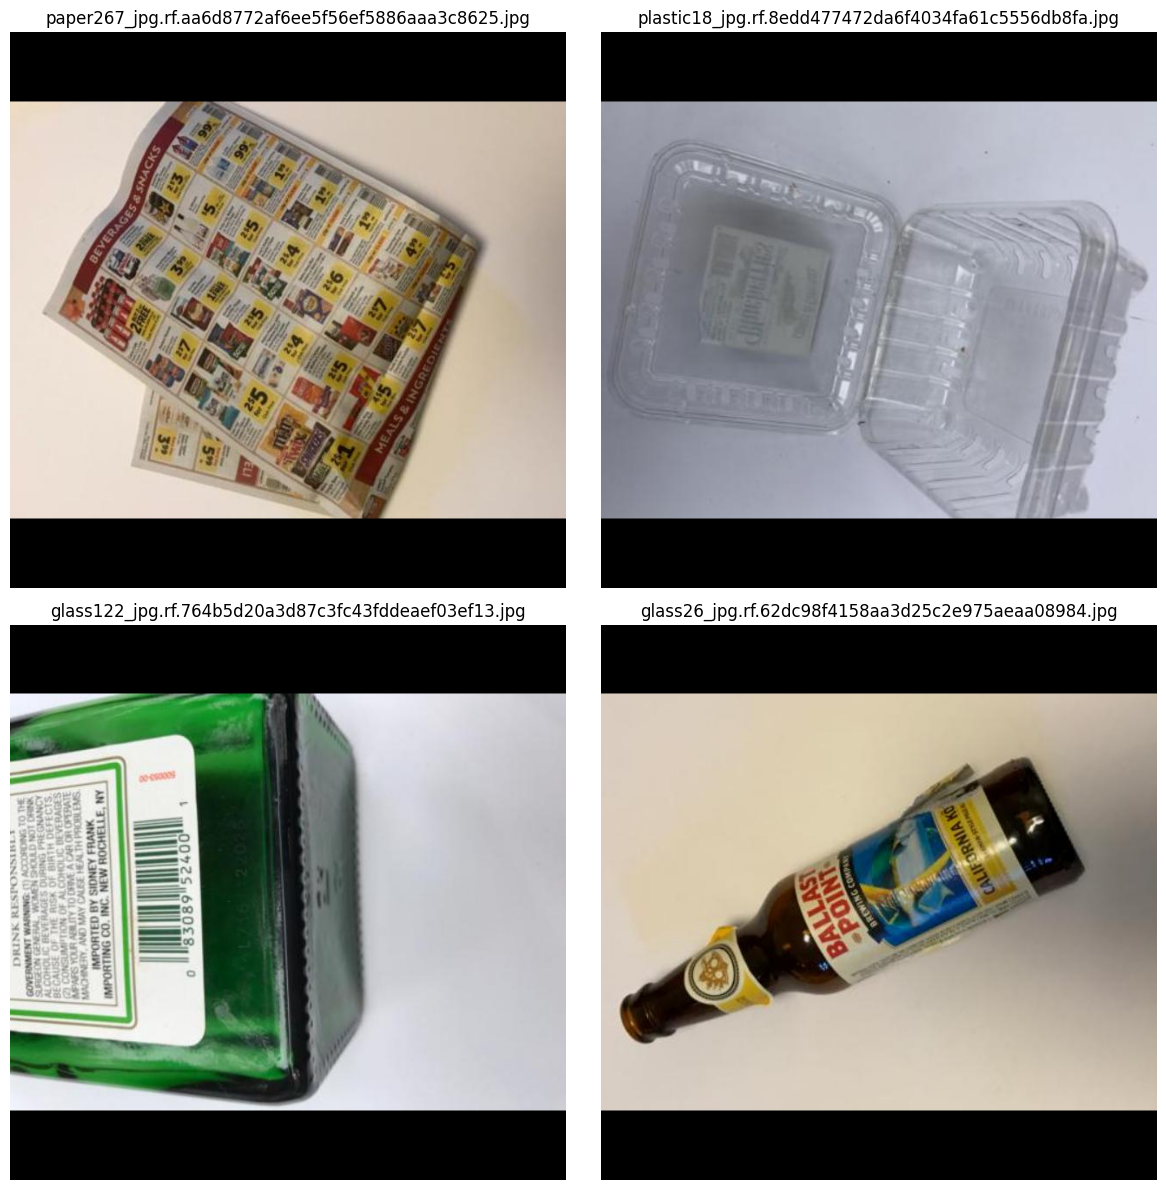

In [2]:
train_images = list(Path(os.path.join(dataset_path, "train/images")).glob("*.*"))
samples = random.sample(train_images, 4)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for ax, img_path in zip(axes.ravel(), samples):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")
plt.tight_layout()
plt.show()

# **Contoh image dengan groundtruth**

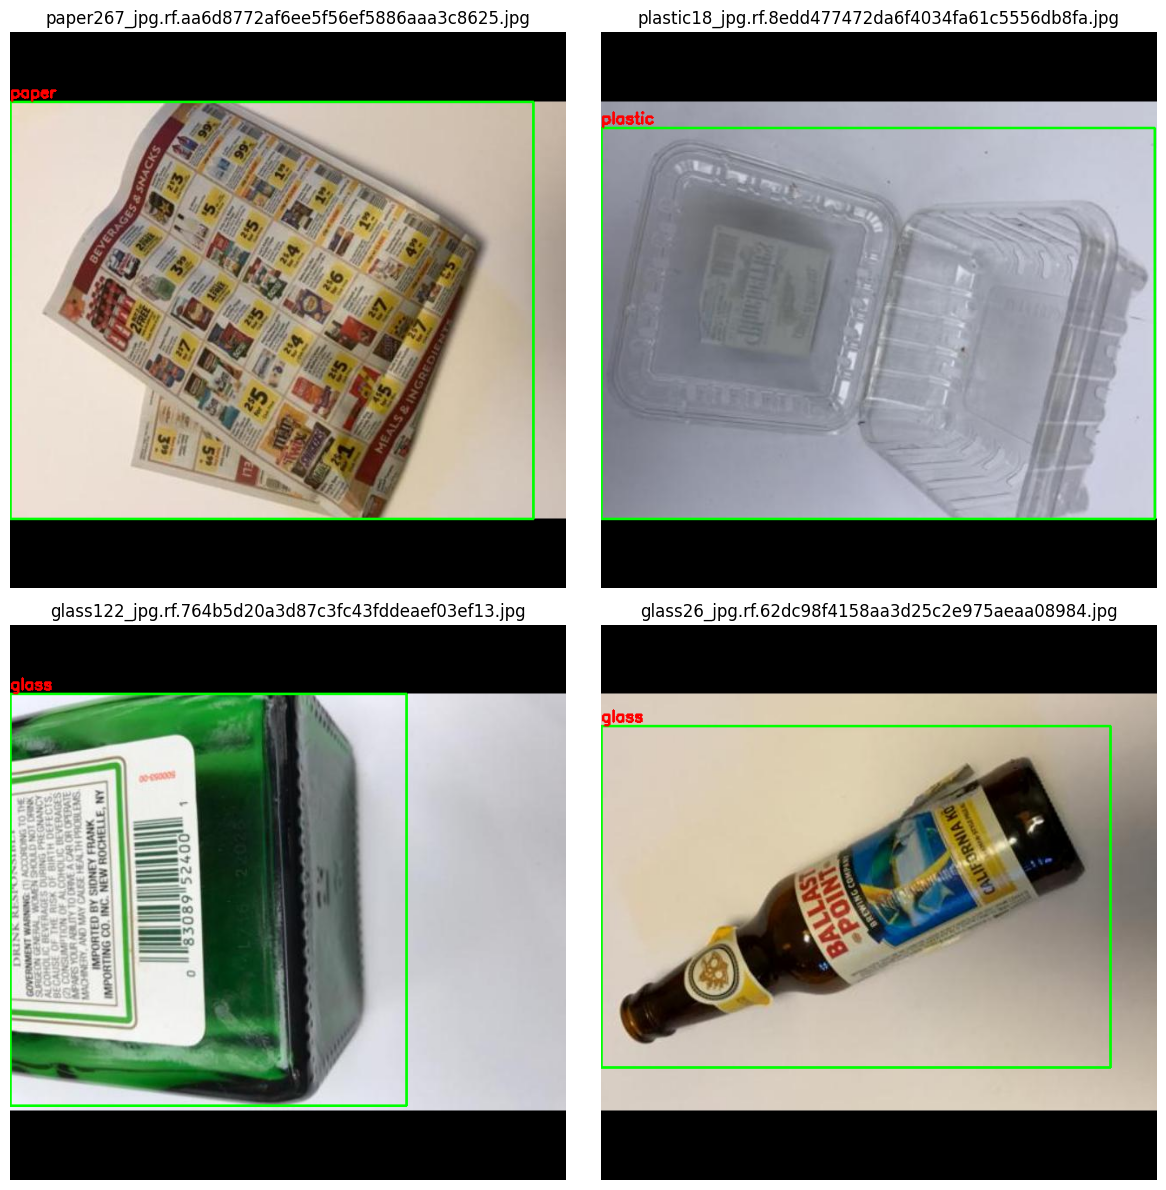

In [3]:
def draw_ground_truth(img_path):
    image = cv2.imread(str(img_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    label_path = str(img_path).replace(
        "/images/",
        "/labels/"
    )

    label_path = os.path.splitext(label_path)[0] + ".txt"

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()
        for line in lines:
            cls, xc, yc, bw, bh = map(float, line.split())
            cls = int(cls)
            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)
            cv2.rectangle(
                image,
                (x1,y1),
                (x2,y2),
                (0,255,0),
                2
            )
            cv2.putText(
                image,
                class_names[cls],
                (x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255,0,0),
                2
            )

    return image

fig, axes = plt.subplots(2,2, figsize=(12,12))
for ax, img_path in zip(axes.ravel(), samples):
    gt_img = draw_ground_truth(img_path)
    ax.imshow(gt_img)
    ax.set_title(img_path.name)
    ax.axis("off")
plt.tight_layout()
plt.show()

# **Training model**

In [4]:
model = YOLO("yolov9s.pt")

results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=640,
    batch=32,
    lr0=0.001,
    optimizer="Adam",
    project="/content/drive/MyDrive/YOLO_TrashNet_V9",
    name="yolov9s_trash"
)

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/TrashNet:-A-set-of-annotated-images-of-trash-that-can-be-used-for-object-detection-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9s_trash, nbs=64, nms

# **Grafik performa training**

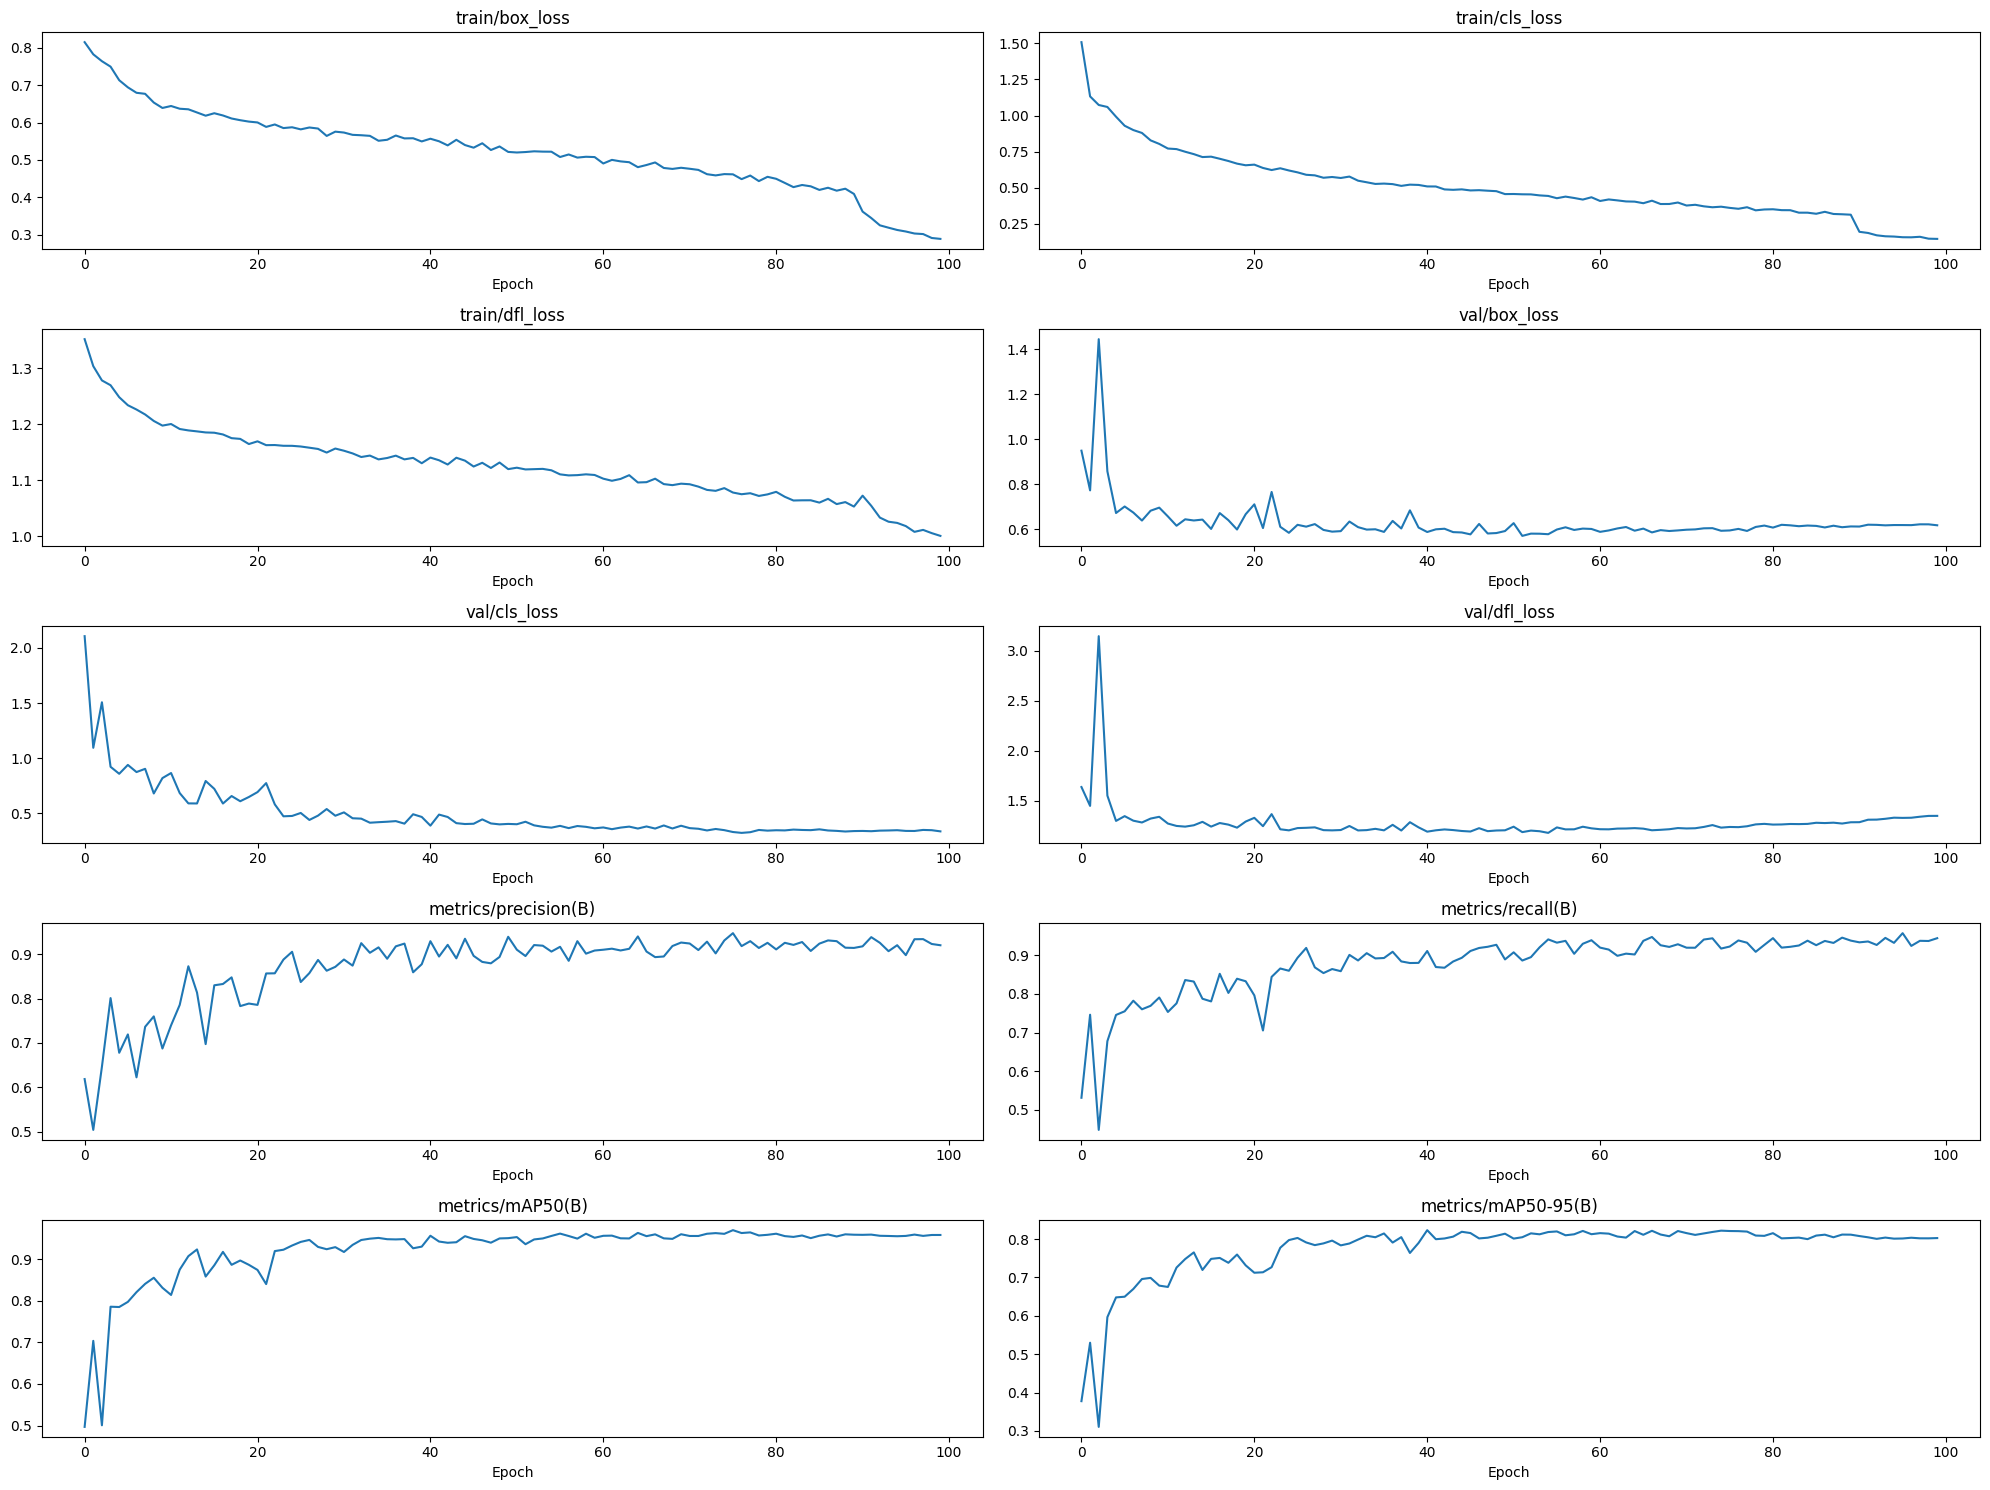

In [11]:
results_csv = pd.read_csv("/content/drive/MyDrive/YOLO_TrashNet_V9/yolov9s_trash/results.csv")


metrics = [
    "train/box_loss",
    "train/cls_loss",
    "train/dfl_loss",
    "val/box_loss",
    "val/cls_loss",
    "val/dfl_loss",
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)"
]

plt.figure(figsize=(20,15))
for i, metric in enumerate(metrics, start=1):
    plt.subplot(5,2,i)
    plt.plot(results_csv[metric])
    plt.title(metric)
    plt.xlabel("Epoch")
plt.tight_layout()
plt.show()

# **Inferensi pada data testing**

In [6]:
test_path = os.path.join(dataset_path, "test/images")

predictions = model.predict(
    source=test_path,
    save=True,
    conf=0.25
)


image 1/264 /content/TrashNet:-A-set-of-annotated-images-of-trash-that-can-be-used-for-object-detection-3/test/images/cardboard11_jpg.rf.a67bd5b62791e16e3e682c5af9f969ab.jpg: 640x640 1 cardboard, 21.5ms
image 2/264 /content/TrashNet:-A-set-of-annotated-images-of-trash-that-can-be-used-for-object-detection-3/test/images/cardboard121_jpg.rf.6a16004173b85e70bdcfc16a4c0efdc5.jpg: 640x640 1 cardboard, 23.7ms
image 3/264 /content/TrashNet:-A-set-of-annotated-images-of-trash-that-can-be-used-for-object-detection-3/test/images/cardboard124_jpg.rf.9087cba2e3179800f0b2af5d54d9dbd0.jpg: 640x640 1 cardboard, 20.0ms
image 4/264 /content/TrashNet:-A-set-of-annotated-images-of-trash-that-can-be-used-for-object-detection-3/test/images/cardboard128_jpg.rf.a10e5967dc8dbaea45292ee57e2db068.jpg: 640x640 1 metal, 1 paper, 20.1ms
image 5/264 /content/TrashNet:-A-set-of-annotated-images-of-trash-that-can-be-used-for-object-detection-3/test/images/cardboard152_jpg.rf.b7c5ad0fdcf7bc0c8b9177d8667ae907.jpg: 640

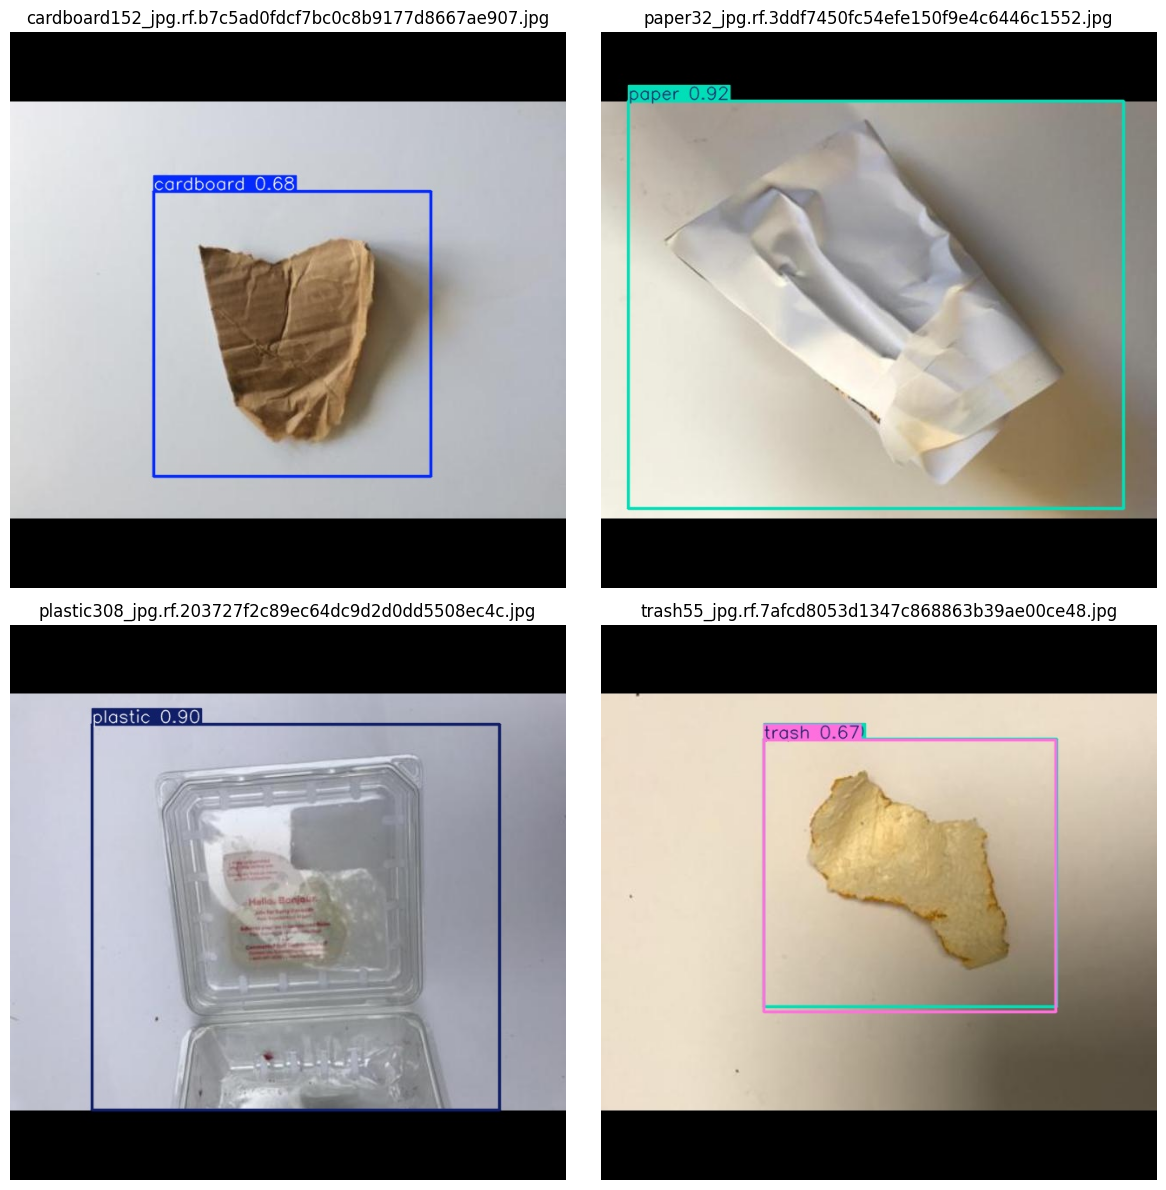

In [7]:
result_images = list(Path("runs/detect/predict").glob("*.*"))

sample_results = random.sample(
    result_images,
    min(4, len(result_images))
)

fig, axes = plt.subplots(2,2, figsize=(12,12))
for ax, img_path in zip(axes.ravel(), sample_results):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")
plt.tight_layout()
plt.show()

# **Confusion Matrix**

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1009.4±395.1 MB/s, size: 20.0 KB)
val: Scanning /content/TrashNet:-A-set-of-annotated-images-of-trash-that-can-be-used-for-object-detection-3/test/labels... 264 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 264/264 2.0Kit/s 0.1s
val: New cache created: /content/TrashNet:-A-set-of-annotated-images-of-trash-that-can-be-used-for-object-detection-3/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 3.2it/s 5.3s
                   all        264        264      0.883      0.905      0.935      0.812
             cardboard         46         46      0.931      0.978      0.983      0.923
                 glass         54         54      0.975       0.87      0.965      0.761
                 metal         39         39      0.915      0.974      0.953      0.841
             

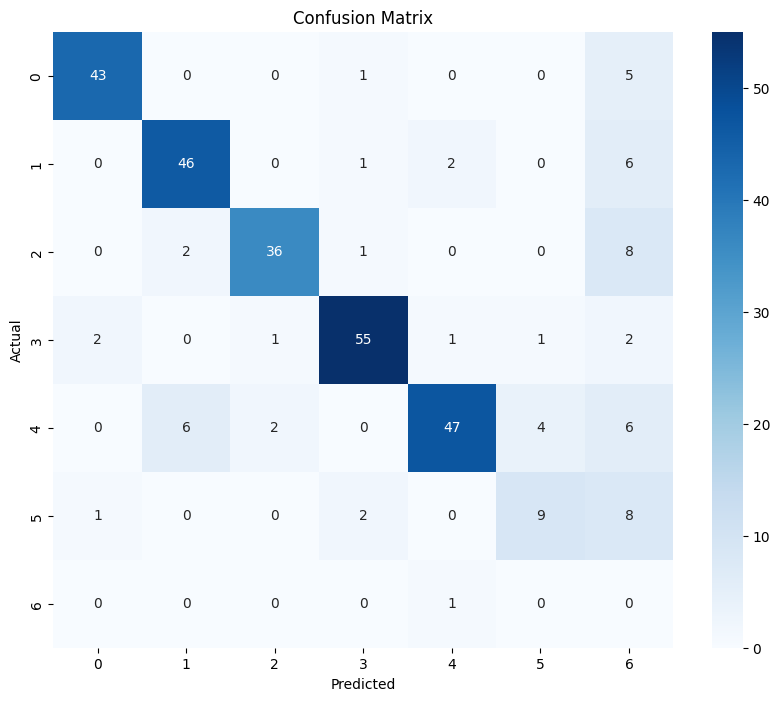

In [8]:
metrics_result = model.val(
    data=yaml_path,
    split="test"
)

confusion_matrix = metrics_result.confusion_matrix.matrix

plt.figure(figsize=(10,8))

import seaborn as sns

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Evaluasi Model**

In [9]:
precision = metrics_result.box.mp
recall = metrics_result.box.mr
map50 = metrics_result.box.map50
map5095 = metrics_result.box.map
f1_score = (2 * precision * recall) / (precision + recall + 1e-16)

print("Hasil Evaluasi:")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1-Score   : {f1_score:.4f}")
print(f"mAP50      : {map50:.4f}")
print(f"mAP50-95   : {map5095:.4f}")

Hasil Evaluasi:
Precision  : 0.8829
Recall     : 0.9050
F1-Score   : 0.8938
mAP50      : 0.9345
mAP50-95   : 0.8122
